<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loaded and split. Test set size: 420

Models loaded successfully.

MODEL COMPARISON
        Model  Accuracy  Precision  Recall  F1-score  ROC AUC  AUPRC
          MLP    0.8810     0.9170  0.8805    0.8984   0.9650 0.9788
Random Forest    0.8810     0.9205  0.8765    0.8980   0.9605 0.9770
      XGBoost    0.8952     0.9157  0.9084    0.9120   0.9709 0.9824


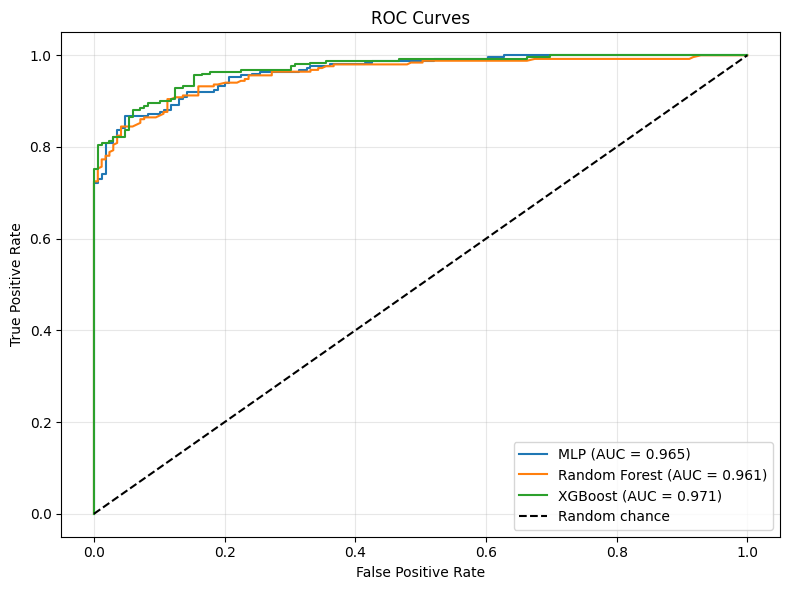

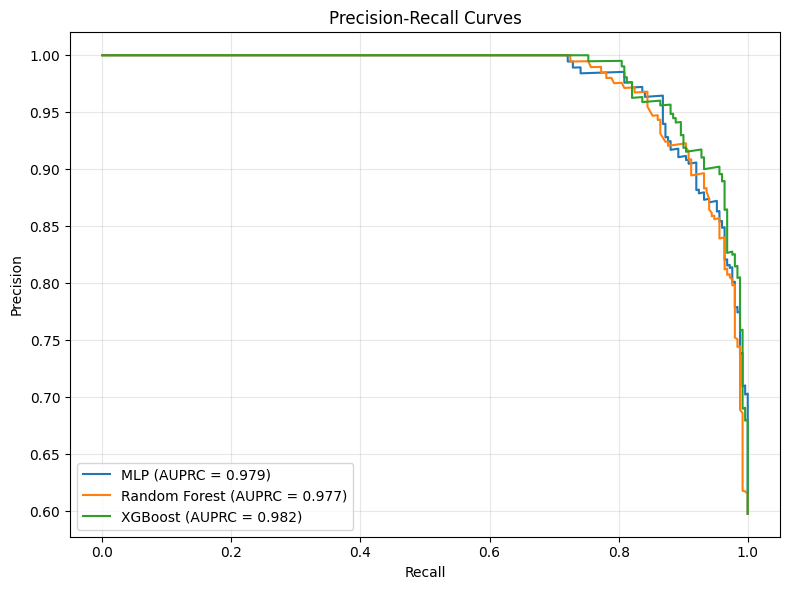

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# ------------------------------
# 1. Load and prepare the dataset
# ------------------------------
DATA_PATH = "Crop_training_data_FULL_1.csv"   # adjust if needed
df = pd.read_csv(DATA_PATH)

# Convert target to binary
df['suitability_class'] = df['suitability_class'].map({'Unsuitable': 0, 'Suitable': 1})

# For the MLP and RF pipelines, we need raw features (categorical untouched)
X_raw = df.drop(columns=['suitability_class', 'suitability'])
y = df['suitability_class']

# For XGBoost, we need one‑hot encoded features (as used during its training)
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# Split into train/test (same random_state as before)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)
X_train_enc, X_test_enc, _, _ = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print("Data loaded and split. Test set size:", len(y_test))

# ------------------------------
# 2. Load the three models
# ------------------------------
mlp_pipeline = joblib.load('Crop api/models/mlp_crop_suitability_pipeline.pkl')
rf_pipeline   = joblib.load('Crop api/models/random_forest_pipeline.pkl')
xgb_model     = joblib.load('Crop api/models/xgboost_model.pkl')

print("\nModels loaded successfully.")

# ------------------------------
# 3. Define evaluation function
# ------------------------------
def evaluate_model(model, X_test, y_test, model_name, proba_needed=True):
    """Compute and return metrics for a model."""
    y_pred = model.predict(X_test)
    if proba_needed:
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if proba_needed else np.nan
    auprc = average_precision_score(y_test, y_proba) if proba_needed else np.nan

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC AUC': roc_auc,
        'AUPRC': auprc
    }, (y_proba if proba_needed else None)

# ------------------------------
# 4. Evaluate each model
# ------------------------------
results = []
proba_dict = {}

# MLP (needs raw features)
metrics, proba = evaluate_model(mlp_pipeline, X_test_raw, y_test, 'MLP')
results.append(metrics)
proba_dict['MLP'] = proba

# Random Forest (needs raw features – pipeline handles preprocessing)
metrics, proba = evaluate_model(rf_pipeline, X_test_raw, y_test, 'Random Forest')
results.append(metrics)
proba_dict['Random Forest'] = proba

# XGBoost (needs encoded features)
metrics, proba = evaluate_model(xgb_model, X_test_enc, y_test, 'XGBoost')
results.append(metrics)
proba_dict['XGBoost'] = proba

# ------------------------------
# 5. Print comparison table
# ------------------------------
df_results = pd.DataFrame(results)
df_results = df_results.round(4)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(df_results.to_string(index=False))

# ------------------------------
# 6. Plot ROC curves
# ------------------------------
plt.figure(figsize=(8, 6))
for name, proba in proba_dict.items():
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------
# 7. Plot Precision‑Recall curves
# ------------------------------
plt.figure(figsize=(8, 6))
for name, proba in proba_dict.items():
    if proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, proba)
        auprc = average_precision_score(y_test, proba)
        plt.plot(recall, precision, label=f'{name} (AUPRC = {auprc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curves')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()